In [196]:
import duckdb
import pandas as pd

In [197]:
feat_con = duckdb.connect(database=":memory:")

In [198]:
feat_con.query(""" CREATE TABLE dpbl_duck AS SELECT * FROM read_csv_auto('data/duckdb_cleaned_dblp.csv')""")
feat_con.query(""" CREATE TABLE train_duck AS SELECT * FROM read_csv_auto('data/train.csv')""")

In [199]:
feat_con.query("""SELECT * FROM dpbl_duck""").show()

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────┬─────────┬────────────────────────────────┬──────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────┬─────────────────────────────────────────────────────────────────┬──────────────────────┬───────────────┐
│                                                        pauthor                                                        │                                                                  ptitle                                                                   │ pyear │   pid   │              pkey              │                 journal                  │                                  journalfull                          

In [200]:
feat_con.query("""SELECT * FROM train_duck""").show()

┌─────────┬──────────────────────────────┬───────────────────────────────────┬─────────┬───────────┐
│ column0 │             key1             │               key2                │  label  │ partition │
│  int64  │           varchar            │              varchar              │ boolean │   int64   │
├─────────┼──────────────────────────────┼───────────────────────────────────┼─────────┼───────────┤
│       0 │ conf/prib/AhmedF07           │ journals/jcc/PatraS09             │ false   │         7 │
│       1 │ conf/vlsid/ChenCC95          │ journals/tcad/LuoCWCCW08          │ true    │         4 │
│       2 │ conf/prozess/Sun88           │ conf/isnn/SunZLCS07               │ true    │         8 │
│       3 │ conf/pricai/BeaumontTSM04    │ conf/icip/SattarAS08              │ false   │         5 │
│       4 │ conf/dft/SemiaoRVSTT07       │ conf/iolts/Rodriguez-IragoAVSTT05 │ true    │         7 │
│       6 │ conf/lmo/DemphlousL96        │ conf/reflection/DemphlousL99      │ true    │   

## JOIN

In [201]:
feat_con.query("""CREATE OR REPLACE TABLE train_pairs AS
                SELECT t.*,
                d1.pauthor AS pauthor_1,
                d1.ptitle AS ptitle_1,
                d1.pyear AS pyear_1,
                d1.ptype AS ptype_1,
                d1.journal AS journal_1,
                d1.journalfull AS journalfull_1,
                d1.booktitle AS booktitle_1,
                d1.booktitlefull AS booktitlefull_1,
               
                d2.pauthor AS pauthor_2,
                d2.ptitle AS ptitle_2,
                d2.pyear AS pyear_2,
                d2.ptype AS ptype_2,
                d2.journal AS journal_2,
                d2.journalfull AS journalfull_2,
                d2.booktitle AS booktitle_2,
                d2.booktitlefull AS booktitlefull_2
                FROM train_duck t
               
               LEFT JOIN dpbl_duck d1 ON t.key1 = d1.pkey
               LEFT JOIN dpbl_duck d2 ON t.key2 = d2.pkey""")

In [202]:
feat_con.query("""SELECT * FROM train_pairs""").show()

┌─────────┬─────────────────────────────────────┬────────────────────────────────────────┬─────────┬───────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┬───────────────┬─────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────┬────────────────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┬───────────────┬───────────────────────────────────────────────────────┬────────────────────────────────────────────────────────

In [203]:
feat_con.sql("SHOW TABLES").show()

┌─────────────┐
│    name     │
│   varchar   │
├─────────────┤
│ dpbl_duck   │
│ train_duck  │
│ train_pairs │
└─────────────┘



In [221]:
train_pairs = feat_con.execute("SELECT * FROM train_pairs").fetchdf()

In [231]:
train_pairs.head()
train_pairs.columns

Index(['column0', 'key1', 'key2', 'label', 'partition', 'pauthor_1',
       'ptitle_1', 'pyear_1', 'ptype_1', 'journal_1', 'journalfull_1',
       'booktitle_1', 'booktitlefull_1', 'pauthor_2', 'ptitle_2', 'pyear_2',
       'ptype_2', 'journal_2', 'journalfull_2', 'booktitle_2',
       'booktitlefull_2', 'title_sim', 'author_jaccard', 'year_diff'],
      dtype='object')

In [224]:
text_cols = ["ptitle_1", "ptitle_2", "pauthor_1", "pauthor_2"]
train_pairs[text_cols] = train_pairs[text_cols].fillna("")

### TODO: check if baseline works similarly in terms of performance

## All original features together to avoid over writing

In [205]:
feat_con.sql("""
CREATE OR REPLACE TABLE train_features AS

WITH exploded AS (
    SELECT 
        key1, key2,
        UNNEST(STRING_SPLIT(COALESCE(pauthor_1, ''), '|')) AS author1,
        UNNEST(STRING_SPLIT(COALESCE(pauthor_2, ''), '|')) AS author2
    FROM train_pairs
),

intersection_counts AS (
    SELECT 
        key1, key2,
        COUNT(DISTINCT author1) AS intersection_size
    FROM exploded
    WHERE author1 = author2 AND author1 != ''
    GROUP BY key1, key2
),

union_counts AS (
    SELECT 
        key1, key2,
        COUNT(DISTINCT author) AS union_size
    FROM (
        SELECT key1, key2, UNNEST(STRING_SPLIT(COALESCE(pauthor_1, ''), '|')) AS author FROM train_pairs
        UNION
        SELECT key1, key2, UNNEST(STRING_SPLIT(COALESCE(pauthor_2, ''), '|')) AS author FROM train_pairs
    )
    WHERE author != ''
    GROUP BY key1, key2
)

SELECT 
    t.*,

    -- Title similarity (NULL-safe)
    CASE 
        WHEN ptitle_1 IS NULL OR ptitle_2 IS NULL THEN 0
        ELSE 1 - (levenshtein(ptitle_1, ptitle_2) 
            / GREATEST(length(ptitle_1), length(ptitle_2)))
    END AS title_sim,

    -- Author Jaccard
    COALESCE(i.intersection_size * 1.0 / NULLIF(u.union_size, 0), 0) AS author_jaccard,

    -- Year difference (NULL-safe)
    CASE 
        WHEN pyear_1 IS NULL OR pyear_2 IS NULL THEN 0
        ELSE ABS(pyear_1 - pyear_2)
    END AS year_diff,

    -- Same journal
    CASE 
        WHEN journal_1 IS NOT NULL AND journal_1 = journal_2 THEN 1 
        ELSE 0 
    END AS same_journal,

    -- Same booktitle
    CASE 
        WHEN booktitle_1 IS NOT NULL AND booktitle_1 = booktitle_2 THEN 1 
        ELSE 0 
    END AS same_booktitle,

    -- Same publication type
    CASE 
        WHEN ptype_1 IS NOT NULL AND ptype_1 = ptype_2 THEN 1 
        ELSE 0 
    END AS same_ptype

FROM train_pairs t
LEFT JOIN intersection_counts i USING (key1, key2)
LEFT JOIN union_counts u USING (key1, key2);
""")

In [ ]:
## df_feat = feat_con.sql("SELECT * FROM train_features").df()

## Just copy pasting for experimental purposes

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words="english")

def title_sim(row):
    t1 = str(row["ptitle_1"]).strip()
    t2 = str(row["ptitle_2"]).strip()
    
    if not t1 or not t2:
        return 0.0
    
    try:
        tfidf = vectorizer.fit_transform([t1, t2])
        return cosine_similarity(tfidf[0], tfidf[1])[0][0]
    except ValueError:
        return 0.0

train_pairs["title_sim"] = train_pairs.apply(title_sim, axis=1)

In [228]:
def author_jaccard(a1, a2):
    if pd.isna(a1) or pd.isna(a2):
        return 0
    
    s1 = set(a1.split("|"))
    s2 = set(a2.split("|"))
    
    return len(s1 & s2) / len(s1 | s2)

train_pairs["author_jaccard"] = train_pairs.apply(
    lambda x: author_jaccard(x["pauthor_1"], x["pauthor_2"]),
    axis=1
)

In [252]:
y1 = pd.to_numeric(train_pairs["pyear_1"], errors="coerce")
y2 = pd.to_numeric(train_pairs["pyear_2"], errors="coerce")

train_pairs["year_missing"] = (y1.isna() | y2.isna()).astype(int)
train_pairs["year_diff"] = (y1 - y2).abs().fillna(0)

In [232]:
train_pairs["same_journal"] = (
    train_pairs["journal_1"] == train_pairs["journal_2"]
).astype(int)

train_pairs["same_journal_full"] = (
    train_pairs["journalfull_1"] == train_pairs["journalfull_2"]
).astype(int)




In [244]:
train_pairs["same_booktitle"] = (
    train_pairs["booktitle_1"] == train_pairs["booktitle_2"]
).astype(int)

train_pairs["same_booktitle_full"] = (
    train_pairs["booktitlefull_1"] == train_pairs["booktitlefull_2"]
).astype(int)

In [245]:
train_pairs["same_ptype"] = (
    train_pairs["ptype_1"] == train_pairs["ptype_2"]
).astype(int)

In [268]:
features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "same_journal",
    "same_journal_full",
    "same_booktitle",
    "same_booktitle_full",
    "same_ptype"
]

X = train_pairs[features]
y = train_pairs["label"]

In [269]:
X.isna().sum()

title_sim              0
author_jaccard         0
year_diff              0
same_journal           0
same_journal_full      0
same_booktitle         0
same_booktitle_full    0
same_ptype             0
dtype: int64

In [270]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2, # 80/20 split since it is standard
    stratify=y,
    random_state=42
)

### Logistic regression

In [271]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [272]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

preds = model.predict_proba(X_val)[:,1]

print("ROC:", roc_auc_score(y_val, preds))
print("Accuracy:", accuracy_score(y_val, preds.round()))
print("Precision:", precision_score(y_val, preds.round()))
print("Recall:", recall_score(y_val, preds.round()))
print("F1 Score:", f1_score(y_val, preds.round()))

ROC: 0.6587814144235093
Accuracy: 0.6288401253918495
Precision: 0.7091295116772823
Recall: 0.4233206590621039
F1 Score: 0.5301587301587302


In [273]:
pd.Series(
    model.coef_[0],
    index=features
).sort_values(ascending=False)

title_sim              7.137632
same_journal           1.319585
same_journal_full      1.319585
author_jaccard         1.095386
same_booktitle         0.424189
same_ptype             0.072333
year_diff             -0.032385
same_booktitle_full   -0.218284
dtype: float64

## Decision tree

In [274]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [275]:
from sklearn.metrics import classification_report
pred = dt.predict(X_val)
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

       False       0.63      0.84      0.72       806
        True       0.75      0.51      0.60       789

    accuracy                           0.67      1595
   macro avg       0.69      0.67      0.66      1595
weighted avg       0.69      0.67      0.66      1595



## Random forest

In [276]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [277]:
preds_rf = rf.predict_proba(X_val)[:, 1]

print("Random Forest Results:")
print(f"  ROC AUC:   {roc_auc_score(y_val, preds_rf):.4f}")
print(f"  Accuracy:  {accuracy_score(y_val, preds_rf.round()):.4f}")
print(f"  Precision: {precision_score(y_val, preds_rf.round()):.4f}")
print(f"  Recall:    {recall_score(y_val, preds_rf.round()):.4f}")
print(f"  F1 Score:  {f1_score(y_val, preds_rf.round()):.4f}")

Random Forest Results:
  ROC AUC:   0.7363
  Accuracy:  0.6702
  Precision: 0.7495
  Recall:    0.5006
  F1 Score:  0.6003


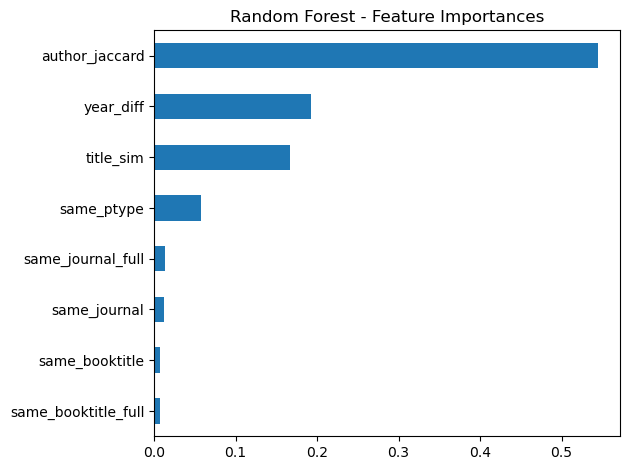

In [278]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind="barh")
plt.title("Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

## XGBoost 

In [279]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [280]:
preds_xgb = xgb.predict_proba(X_val)[:, 1]

print("XGBoost Results:")
print(f"  ROC AUC:   {roc_auc_score(y_val, preds_xgb):.4f}")
print(f"  Accuracy:  {accuracy_score(y_val, preds_xgb.round()):.4f}")
print(f"  Precision: {precision_score(y_val, preds_xgb.round()):.4f}")
print(f"  Recall:    {recall_score(y_val, preds_xgb.round()):.4f}")
print(f"  F1 Score:  {f1_score(y_val, preds_xgb.round()):.4f}")

XGBoost Results:
  ROC AUC:   0.7408
  Accuracy:  0.6721
  Precision: 0.7538
  Recall:    0.5006
  F1 Score:  0.6017


same_journal_full      0.000000
same_booktitle         0.004813
same_booktitle_full    0.005101
title_sim              0.018120
same_journal           0.021892
year_diff              0.027962
same_ptype             0.070726
author_jaccard         0.851387
dtype: float32


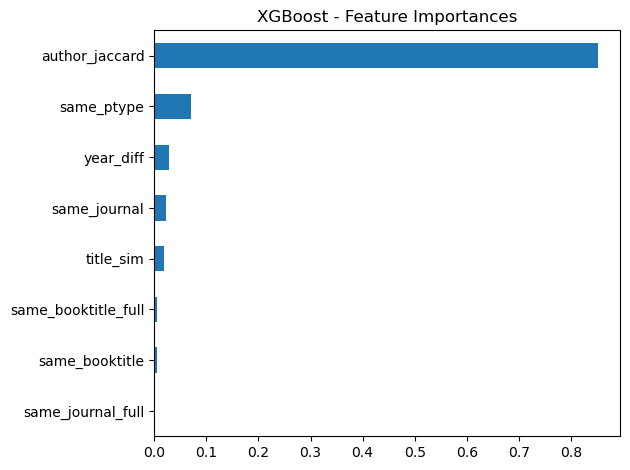

In [281]:
import matplotlib.pyplot as plt
importances_xgb = pd.Series(xgb.feature_importances_, index=features).sort_values()
importances_xgb.plot(kind="barh")
print(importances_xgb)
plt.title("XGBoost - Feature Importances")
plt.tight_layout()
plt.show()